<a href="https://colab.research.google.com/github/gokulraaj0401-svg/Smart-Weather-Prediction/blob/main/AIML_CT_project_07_07_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Weather Prediction**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving seattle-weather.csv to seattle-weather.csv


In [ ]:
df = pd.read_csv('seattle-weather.csv')

In [ ]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
# ===========================================
# STEP 1: DATA ANALYSIS
# ===========================================

# Import Libraries
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('/content/seattle-weather.csv')

# Display Dataset
df

# First 5 Rows
df.head()

# Last 5 Rows
df.tail()

# Shape
print("Shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Dataset Information
print("\nDataset Info:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
df.describe()

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# Unique Values
print("\nUnique Values:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Shape: (1461, 6)

Columns:
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Data Types:
date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB

Statistical Summary:

Missing Values:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Duplicate R

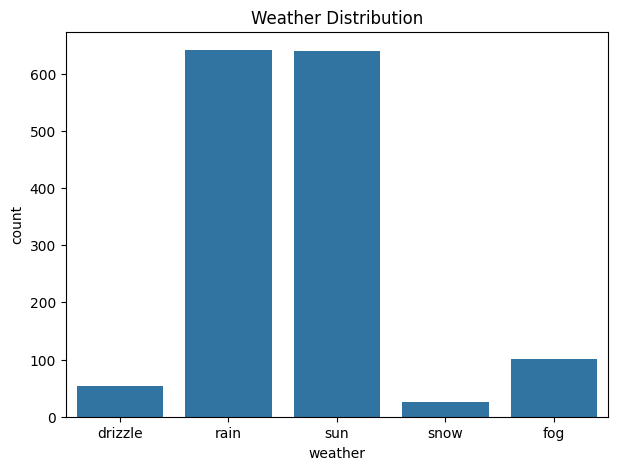

               precipitation  temp_max  temp_min      wind
precipitation       1.000000 -0.228555 -0.072684  0.328045
temp_max           -0.228555  1.000000  0.875687 -0.164857
temp_min           -0.072684  0.875687  1.000000 -0.074185
wind                0.328045 -0.164857 -0.074185  1.000000


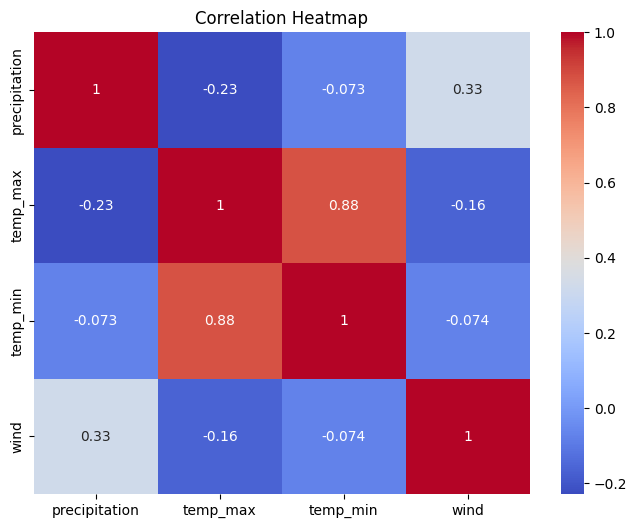

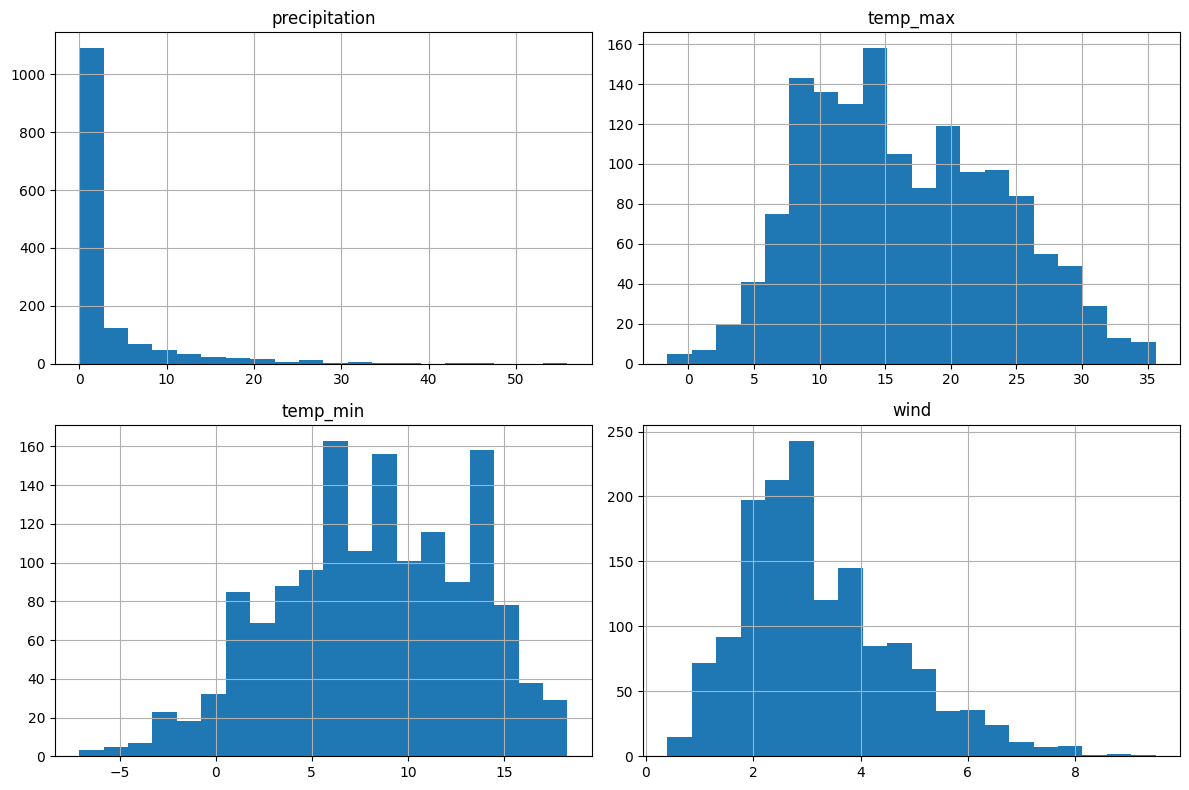

In [ ]:
# ===========================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ===========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Target Variable Distribution
plt.figure(figsize=(7,5))
sns.countplot(x='weather', data=df)
plt.title("Weather Distribution")
plt.show()

# Correlation Matrix
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

print(corr)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Histograms
numeric_df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

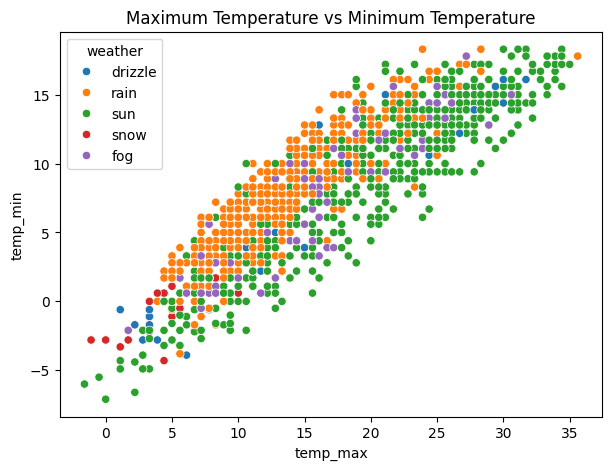

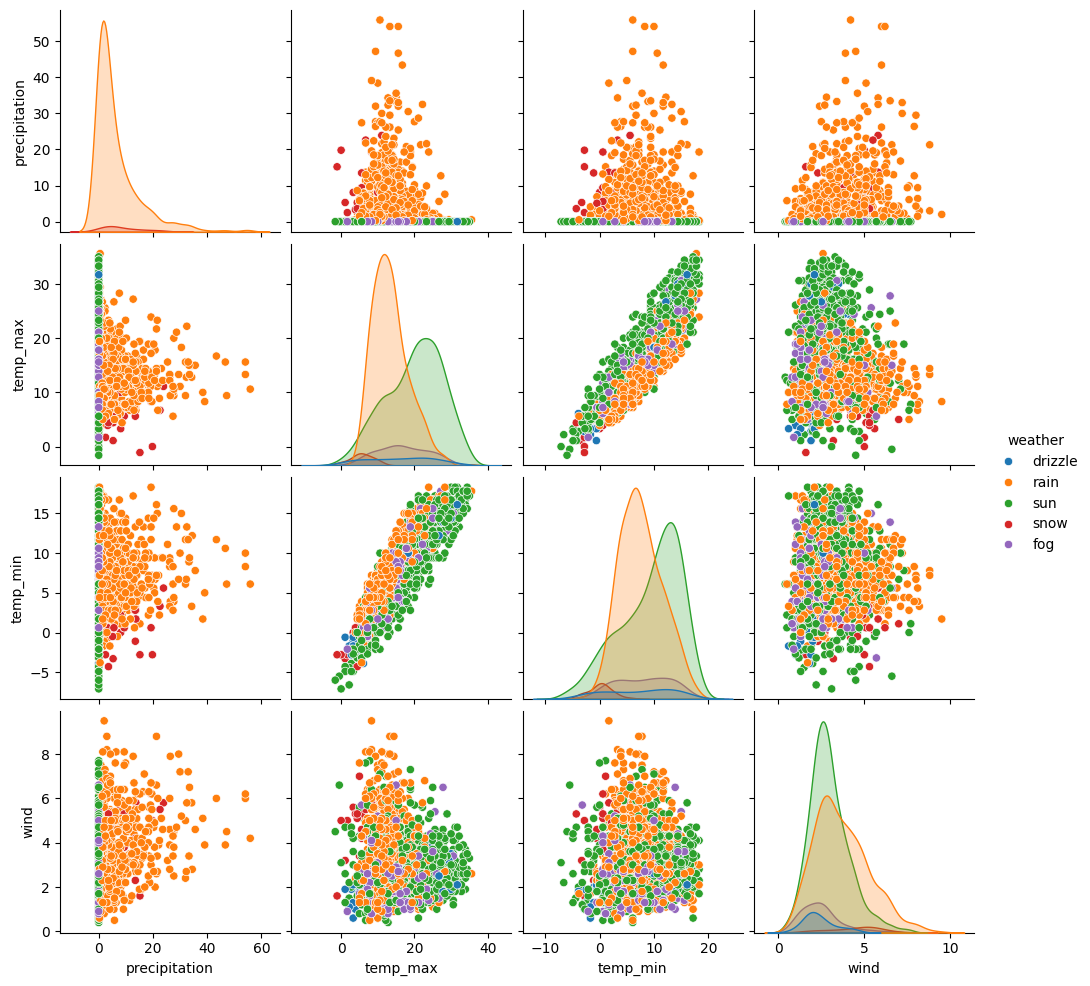

/tmp/ipykernel_2360/1015547977.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['temp_max'], shade=True)


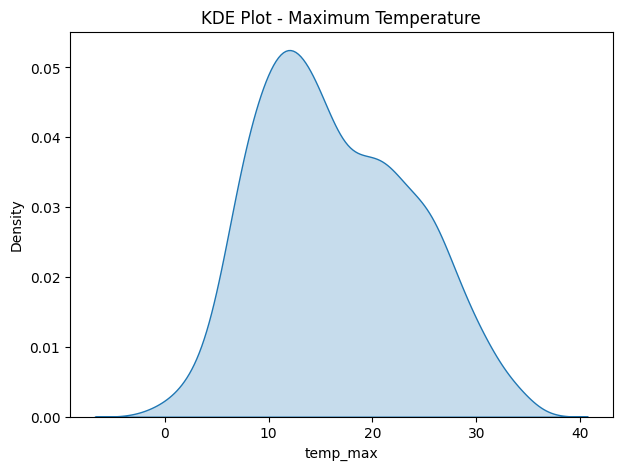

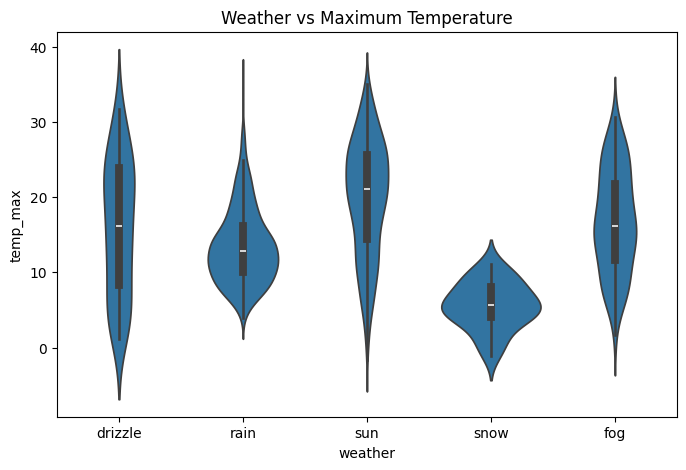

In [ ]:
# ===========================================
# STEP 3: FEATURE RELATIONSHIP ANALYSIS
# ===========================================

# Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x='temp_max', y='temp_min', hue='weather', data=df)
plt.title("Maximum Temperature vs Minimum Temperature")
plt.show()

# Pair Plot
sns.pairplot(df, hue='weather')
plt.show()

# KDE Plot
plt.figure(figsize=(7,5))
sns.kdeplot(df['temp_max'], shade=True)
plt.title("KDE Plot - Maximum Temperature")
plt.show()

# Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(x='weather', y='temp_max', data=df)
plt.title("Weather vs Maximum Temperature")
plt.show()

In [ ]:
# ===========================================
# STEP 4: REMOVE OUTLIERS
# ===========================================

numeric_columns = numeric_df.columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:")
print(df.shape)

Dataset Shape After Removing Outliers:
(1211, 6)


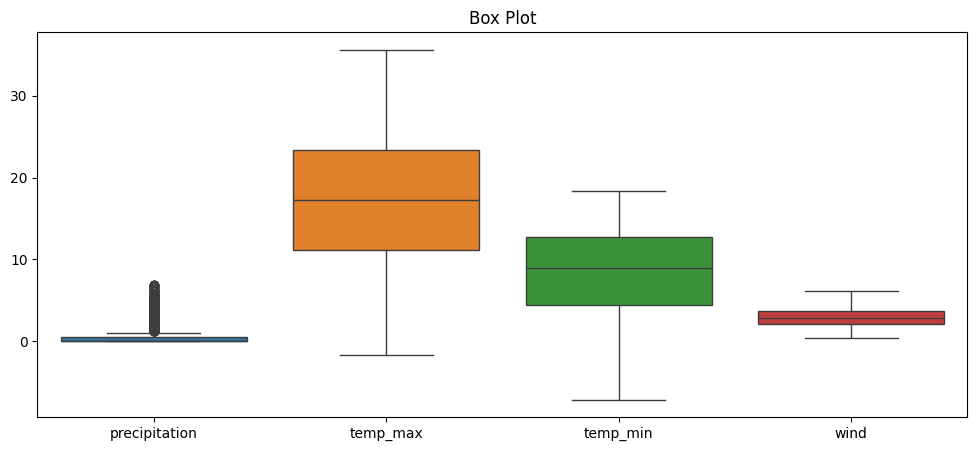

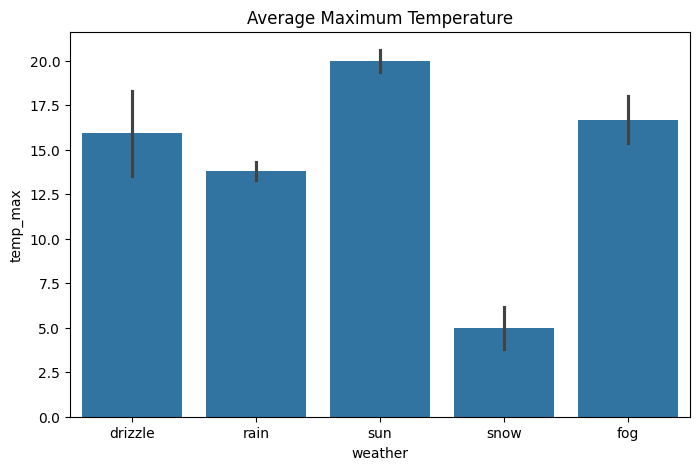

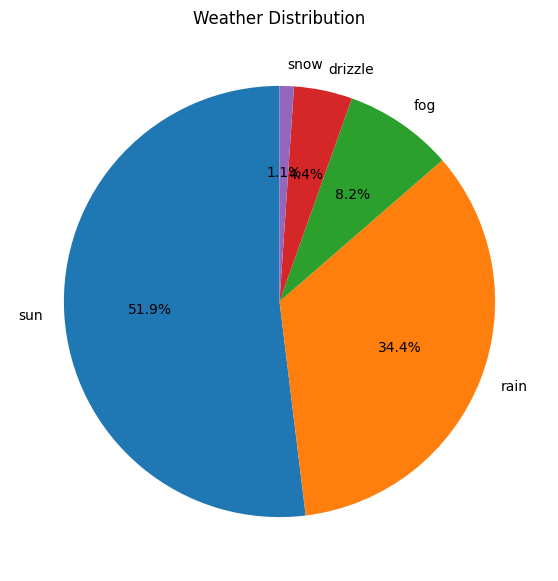

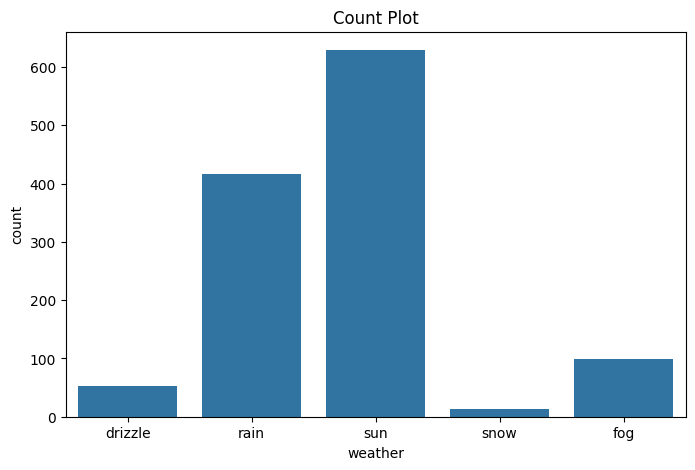

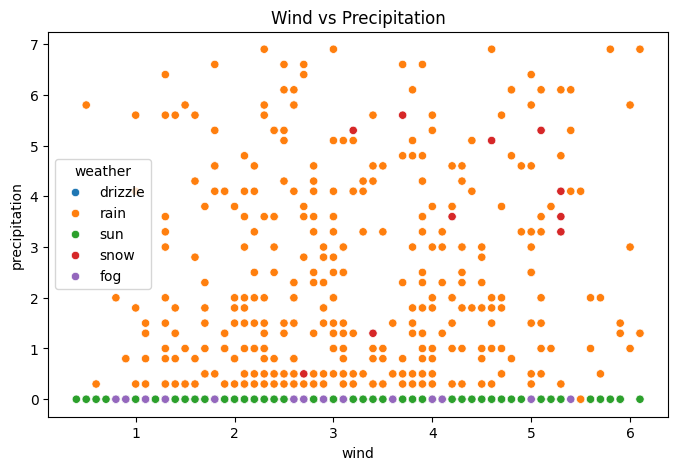

In [ ]:
# ===========================================
# STEP 5: DATA VISUALIZATION
# ===========================================

# Box Plot
plt.figure(figsize=(12,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Box Plot")
plt.show()

# Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(x='weather', y='temp_max', data=df)
plt.title("Average Maximum Temperature")
plt.show()

# Pie Chart
weather_counts = df['weather'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(weather_counts,
        labels=weather_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Weather Distribution")
plt.show()

# Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x='weather', data=df)
plt.title("Count Plot")
plt.show()

# Scatter Plot (Wind vs Precipitation)
plt.figure(figsize=(8,5))
sns.scatterplot(x='wind', y='precipitation', hue='weather', data=df)
plt.title("Wind vs Precipitation")
plt.show()

Machine Learning Workflow

In [ ]:
#Step 1 : Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv("/content/seattle-weather.csv")

# Display first 5 rows
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [ ]:
# Step 2: Load Dataset

import pandas as pd

# Read the CSV file
df = pd.read_csv("/content/seattle-weather.csv")

# Display the first 5 rows
print(df.head(5))

# Display the last 5 rows
print(df.tail(5))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            8.6       4.4       1.7   2.9    rain
1457  2015-12-28            1.5       5.0       1.7   1.3    rain
1458  2015-12-29            0.0       7.2       0.6   2.6     fog
1459  2015-12-30            0.0       5.6      -1.0   3.4     sun
1460  2015-12-31            0.0       5.6      -2.1   3.5     sun


In [ ]:
# Step 3: Understand Dataset

# Shape of the dataset
print("Shape of the dataset:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types of each column
print("\nData Types:")
print(df.dtypes)

# Information about the dataset
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Shape of the dataset:
(1461, 6)

Columns:
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Data Types:
date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB

Statistical Summary:
       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.

Missing Values:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Duplicate Values:
0

Correlation Matrix:
               precipitation  temp_max  temp_min      wind
precipitation       1.000000 -0.228555 -0.072684  0.328045
temp_max           -0.228555  1.000000  0.875687 -0.164857
temp_min           -0.072684  0.875687  1.000000 -0.074185
wind                0.328045 -0.164857 -0.074185  1.000000


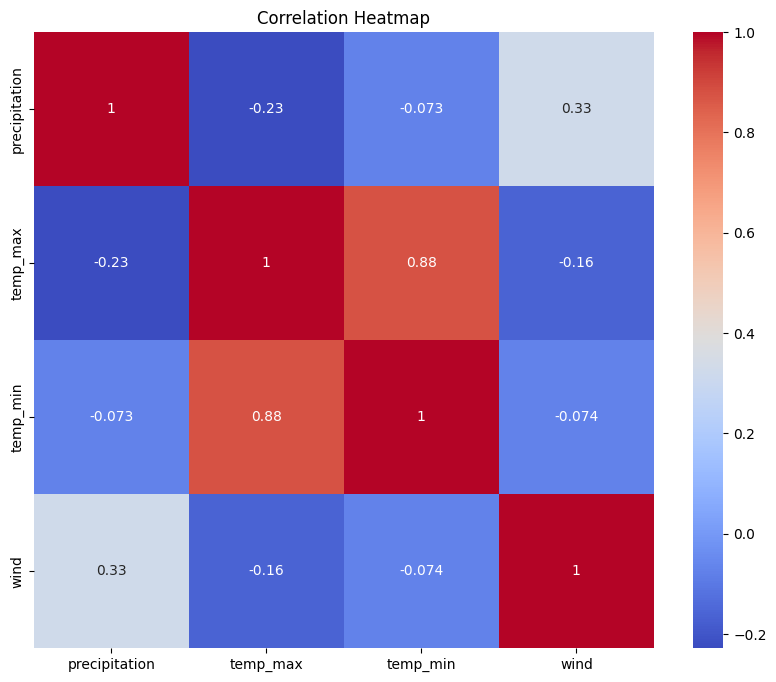

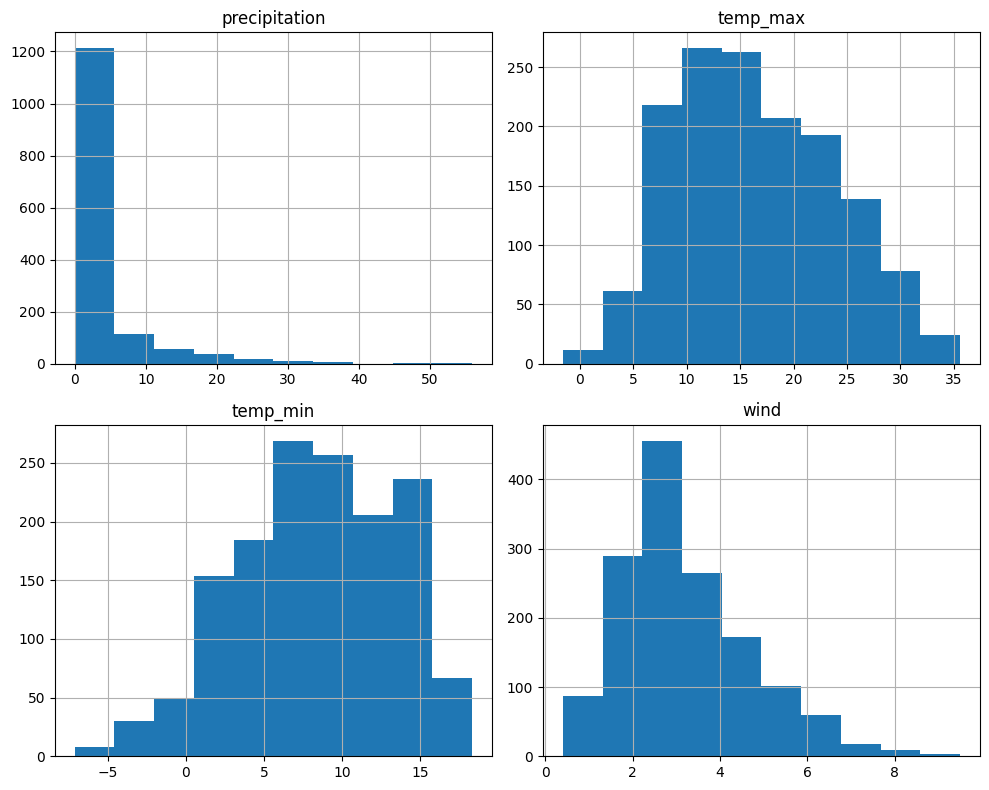

In [ ]:
# Step 4: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt

# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# Check Duplicate Values
print("\nDuplicate Values:")
print(df.duplicated().sum())

# Correlation Matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histogram
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Data Cleaning

# Remove missing values
df.dropna(inplace=True)

# Fill missing values (for numeric columns)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove outliers using the IQR method on 'temp_max'

Q1 = df["temp_max"].quantile(0.25)
Q3 = df["temp_max"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["temp_max"] >= lower) & (df["temp_max"] <= upper)]

# Display the cleaned dataset
print(df.head())

# Check the new shape
print("Dataset Shape:", df.shape)

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
Dataset Shape: (1461, 6)


In [ ]:
# Step 6: Feature Engineering

# Create a new feature: Temperature Range
df["temp_range"] = df["temp_max"] - df["temp_min"]

# Display the first 5 rows
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather  temp_range
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle         7.8
1  2012-01-02           10.9      10.6       2.8   4.5     rain         7.8
2  2012-01-03            0.8      11.7       7.2   2.3     rain         4.5
3  2012-01-04           20.3      12.2       5.6   4.7     rain         6.6
4  2012-01-05            1.3       8.9       2.8   6.1     rain         6.1


In [ ]:
# Step 7: Feature Selection

# Independent Variables (Features)
X = df[["precipitation", "temp_max", "temp_min", "wind"]]

# Dependent Variable (Target)
y = df["weather"]

# Display the features and target
print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   precipitation  temp_max  temp_min  wind
0            0.0      12.8       5.0   4.7
1           10.9      10.6       2.8   4.5
2            0.8      11.7       7.2   2.3
3           20.3      12.2       5.6   4.7
4            1.3       8.9       2.8   6.1

Dependent Variable (y):
0    drizzle
1       rain
2       rain
3       rain
4       rain
Name: weather, dtype: object


In [ ]:
# Step 8: Encoding

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode the target variable (weather)
y = le.fit_transform(y)

# Display the encoded values
print("Encoded Target Variable:")
print(y[:10])

# Display the class mapping
print("\nClass Labels:")
for i, label in enumerate(le.classes_):
    print(f"{label} = {i}")

Encoded Target Variable:
[0 2 2 2 2 2 2 4 2 2]

Class Labels:
drizzle = 0
fog = 1
rain = 2
snow = 3
sun = 4


In [ ]:
# Step 9: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the independent variables
X = scaler.fit_transform(X)

# Display the scaled features
print(X[:5])

[[-0.45364986 -0.49529914 -0.64421175  1.01497975]
 [ 1.17859791 -0.79473121 -1.08234662  0.87583314]
 [-0.33385186 -0.64501518 -0.20607688 -0.65477956]
 [ 2.58622442 -0.57696243 -0.52472042  1.01497975]
 [-0.2589781  -1.02611054 -1.08234662  1.98900601]]


In [ ]:
# Step 10: Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shape of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1168, 4)
X_test shape : (293, 4)
y_train shape: (1168,)
y_test shape : (293,)


**RANDOM FOREST ALGORITHM

In [ ]:
#STEP 11
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Step 12: Train the Model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Step 13: Prediction

# Predict the target values for the test dataset
y_pred = model.predict(X_test)

# Display the predicted values
print("Predicted Values:")
print(y_pred)

Predicted Values:
[4 2 2 0 2 2 4 4 2 4 4 4 2 4 4 2 4 2 4 4 2 4 2 4 4 2 4 4 4 4 2 4 4 3 4 2 2
 2 2 4 2 4 4 4 4 2 2 4 2 4 4 2 4 2 4 2 2 4 2 4 2 4 2 4 4 4 2 4 2 2 2 4 4 2
 2 4 2 4 2 2 2 4 2 4 2 4 4 2 4 2 2 4 4 2 2 4 4 2 4 2 4 4 2 3 2 4 4 2 4 2 2
 4 2 2 4 0 4 4 4 2 2 2 2 2 4 4 4 4 4 4 4 4 4 0 4 4 2 2 2 4 4 4 2 2 4 1 4 2
 4 4 2 4 4 4 2 3 1 4 2 2 1 4 2 4 1 2 2 4 4 4 2 2 4 4 2 2 4 4 0 2 4 4 4 2 2
 4 2 2 4 4 4 4 4 2 4 4 4 2 2 2 2 4 0 2 4 2 2 4 3 4 2 4 4 4 4 4 4 4 2 4 2 4
 4 4 4 2 4 2 4 3 4 2 4 4 2 4 4 4 4 4 2 2 4 2 4 4 4 4 2 2 2 2 2 4 4 4 2 4 2
 2 2 2 4 2 4 4 2 1 4 4 4 1 4 2 4 4 2 2 4 4 4 2 4 2 4 4 2 4 4 2 4 2 4]


In [ ]:
# Step 14: Accuracy

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Accuracy:", accuracy)

# Display accuracy as a percentage
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.8191126279863481
Accuracy Percentage: 81.91126279863481 %


In [ ]:
# Step 15: Confusion Matrix

from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  1   0   0   0   8]
 [  1   3   1   0  20]
 [  0   0 110   3   7]
 [  0   0   6   2   0]
 [  3   3   1   0 124]]


In [ ]:
# Step 16: Classification Report

from sklearn.metrics import classification_report

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.11      0.14         9
           1       0.50      0.12      0.19        25
           2       0.93      0.92      0.92       120
           3       0.40      0.25      0.31         8
           4       0.78      0.95      0.86       131

    accuracy                           0.82       293
   macro avg       0.56      0.47      0.48       293
weighted avg       0.79      0.82      0.79       293



In [ ]:
# Step 17: Predict New Weather

# New data:
# [precipitation, temp_max, temp_min, wind]
new_data = [[2.5, 20.0, 10.0, 4.5]]

# Scale the new data
new_data = scaler.transform(new_data)

# Predict the weather
prediction = model.predict(new_data)

# Convert the encoded prediction back to the original weather label
predicted_weather = le.inverse_transform(prediction)

print("Predicted Weather:", predicted_weather[0])

Predicted Weather: rain


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Step 18: Save the Model

import joblib

# Save the trained model
joblib.dump(model, "weather_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Step 19: Load Saved Model

import joblib

# Load the saved model
model = joblib.load("weather_prediction_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!
